# VoiceForge -- Day 9: DPO Training

**Goal for today:** align the SFT model further using the preference
pairs from Day 7-8 -- continuing from the SFT adapter (not the raw base
model), training with `DPOTrainer`, then comparing base vs. SFT vs.
SFT+DPO on the same held-out prompts to see whether this stage
actually moved anything.

Self-contained, like Day 6-7. **Before running:** `Runtime > Change
runtime type > T4 GPU`, `HF_TOKEN` Colab secret set.


## 1. Install dependencies

In [1]:
!pip install -q -U transformers accelerate peft trl bitsandbytes datasets huggingface_hub matplotlib


     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 80.3/80.3 kB 6.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 11.7/11.7 MB 73.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 925.8/925.8 kB 30.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 41.0/41.0 MB 17.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 559.1/559.1 kB 22.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 793.2/793.2 kB 28.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 10.0/10.0 MB 47.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 50.1/50.1 MB 11.8 MB/s eta 0:00:00


## 2. GPU check

In [2]:
import torch

assert torch.cuda.is_available(), "No GPU detected -- set Runtime > Change runtime type > T4 GPU."
print("GPU:", torch.cuda.get_device_name(0))
total_vram_gb = torch.cuda.get_device_properties(0).total_memory / 1e9
print(f"VRAM: {total_vram_gb:.1f} GB")

major, minor = torch.cuda.get_device_capability()
USE_BF16 = major >= 8
COMPUTE_DTYPE = torch.bfloat16 if USE_BF16 else torch.float16
print(f"Compute capability: {major}.{minor} -> using {'bf16' if USE_BF16 else 'fp16'}")


GPU: Tesla T4
VRAM: 15.6 GB
Compute capability: 7.5 -> using fp16


## 3. Mount Drive, log in, load the DPO preference dataset

In [3]:
from google.colab import drive
drive.mount("/content/drive")

from pathlib import Path
DRIVE_PROJECT_DIR = "/content/drive/MyDrive/voiceforge"
DPO_CHECKPOINT_DIR = f"{DRIVE_PROJECT_DIR}/dpo_checkpoints"
Path(DPO_CHECKPOINT_DIR).mkdir(parents=True, exist_ok=True)


Mounted at /content/drive


In [4]:
from huggingface_hub import login
from google.colab import userdata

login(token=userdata.get("HF_TOKEN"))

from datasets import load_dataset

DPO_DATASET_REPO = "bikalpoudel/voiceforge-brand-voice-dpo"
SFT_DATASET_REPO = "bikalpoudel/voiceforge-brand-voice-sft"  # for the Day 10-style held-out test prompts later

dpo_ds = load_dataset(DPO_DATASET_REPO)
sft_ds = load_dataset(SFT_DATASET_REPO)
print(dpo_ds)
print()
print("Example brief:   ", dpo_ds["train"][0]["brief"])
print("Example chosen:  ", dpo_ds["train"][0]["chosen"])
print("Example rejected:", dpo_ds["train"][0]["rejected"])


README.md:   0%|          | 0.00/1.37k [00:00<?, ?B/s]

Repo card metadata block was not found. Setting CardData to empty.


data/train-00000-of-00001.parquet: reconstructing file:   0%|          |  0.00B / 73.0kB            

data/train-00000-of-00001.parquet: downloading bytes:           |  0.00B            

data/validation-00000-of-00001.parquet: reconstructing file:   0%|          |  0.00B / 18.4kB            

...

data/test-00000-of-00001.parquet: downloading bytes:           |  0.00B            

Generating train split:   0%|          | 0/194 [00:00<?, ? examples/s]

Generating validation split:   0%|          | 0/24 [00:00<?, ? examples/s]

Generating test split:   0%|          | 0/25 [00:00<?, ? examples/s]

DatasetDict({
    train: Dataset({
        features: ['id', 'voice', 'voice_tag', 'format', 'product', 'angle', 'brief', 'chosen', 'rejected', 'chosen_source', 'label_method', 'reason'],
        num_rows: 216
    })
    validation: Dataset({
        features: ['id', 'voice', 'voice_tag', 'format', 'product', 'angle', 'brief', 'chosen', 'rejected', 'chosen_source', 'label_method', 'reason'],
        num_rows: 23
    })
})

Example brief:    [Voice: Cozy Crochet] Write a TikTok caption (15-30 words) for a crochet scarf. Campaign angle: new design reveal. A light CTA is okay here if it fits naturally, but isn't required.
Example chosen:   I'm so excited to share this new colorway for my favorite cold-weather accessory 🧶 It's handmade with love in soft acrylic yarn. DM to order!
Example rejected: New scarf stitch is here to keep you warm all through this cold season. Every single one takes around twelve hours of cozy thought. Send me your favorite color in the DM for your reference thread!

## 4. System prompts (must match SFT training -- copied verbatim from Day 6/7)


In [5]:
DISTILLED_SYSTEM_PROMPTS = {
    "cozy_crochet": (
        "You are a copywriter for a cozy handmade crochet shop. Voice: genuine, "
        "cozy, cute, simple, thoughtful. Short sentences, contractions and "
        "fragments are fine. Emoji: choose from \U0001F9F6 \U0001F338 \u2728 \U0001F49B, max 1-2 per post. Never say: "
        "elevate, premium, luxurious, game-changer, exclusive drop. Include one "
        "concrete detail (size, turnaround time, or material) when the format "
        "calls for it. Output only the copy itself, no labels or quotation marks."
    ),
    "romantic_floral": (
        "You are a copywriter for a romantic handmade bouquet shop. Voice: "
        "sentimental, heartfelt, aesthetic, warm, custom-focused. Emoji: choose "
        "from \U0001F490 \U0001F380 \U0001F48C \u2728, max 1-2 per post. Never say: unlock, revolutionary, "
        "unrivaled, cheap, bulk, flash sale. Include one concrete detail (size, "
        "turnaround time, or materials) when the format calls for it. Output "
        "only the copy itself, no labels or quotation marks."
    ),
}


## 5. Load base model in 4-bit + attach the SFT adapter as the starting point

DPO continues from the SFT adapter's weights rather than starting from
raw base -- loaded here as a **trainable** PEFT model (not
`PeftModel.from_pretrained` in inference mode like Day 7's candidate
generation), so training updates these same LoRA weights further.


In [6]:
from transformers import AutoTokenizer, AutoModelForCausalLM, BitsAndBytesConfig
from peft import PeftModel

BASE_MODEL = "Qwen/Qwen2.5-7B-Instruct"
SFT_ADAPTER_REPO = "bikalpoudel/voiceforge-brand-voice-sft-lora"

bnb_config = BitsAndBytesConfig(
    load_in_4bit=True,
    bnb_4bit_quant_type="nf4",
    bnb_4bit_compute_dtype=COMPUTE_DTYPE,
    bnb_4bit_use_double_quant=True,
)

tokenizer = AutoTokenizer.from_pretrained(BASE_MODEL)
if tokenizer.pad_token is None:
    tokenizer.pad_token = tokenizer.eos_token

base_model = AutoModelForCausalLM.from_pretrained(
    BASE_MODEL,
    quantization_config=bnb_config,
    device_map="auto",
    dtype=COMPUTE_DTYPE,
)
base_model.config.use_cache = False

model = PeftModel.from_pretrained(base_model, SFT_ADAPTER_REPO, is_trainable=True)
print(f"Loaded {BASE_MODEL} + trainable SFT adapter {SFT_ADAPTER_REPO}")
print(f"Memory allocated: {torch.cuda.memory_allocated() / 1e9:.2f} GB")


config.json:   0%|          | 0.00/663 [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/7.30k [00:00<?, ?B/s]

vocab.json:   0%|          | 0.00/2.78M [00:00<?, ?B/s]

merges.txt:   0%|          | 0.00/1.67M [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/7.03M [00:00<?, ?B/s]

...

generation_config.json:   0%|          | 0.00/243 [00:00<?, ?B/s]

adapter_config.json:   0%|          | 0.00/1.16k [00:00<?, ?B/s]

adapter_model.safetensors: reconstructing file:   0%|          |  0.00B /  162MB            

adapter_model.safetensors: downloading bytes:           |  0.00B            

Loaded Qwen/Qwen2.5-7B-Instruct + trainable SFT adapter bikalpoudel/voiceforge-brand-voice-sft-lora
Memory allocated: 5.72 GB


## 6. Format the dataset for DPOTrainer

`DPOTrainer` wants `prompt`, `chosen`, `rejected` as plain template
strings here (same "template it yourself" choice as Day 5-6's SFT
formatting, for the same reason -- consistent behavior across trl
versions rather than relying on its auto-detection of conversational
columns). `prompt` includes `add_generation_prompt=True` so the model's
turn starts cleanly; `chosen`/`rejected` are just the raw completion text.


In [7]:
def build_dpo_row(example):
    messages = [
        {"role": "system", "content": DISTILLED_SYSTEM_PROMPTS[example["voice"]]},
        {"role": "user", "content": example["brief"]},
    ]
    prompt = tokenizer.apply_chat_template(messages, tokenize=False, add_generation_prompt=True)
    return {"prompt": prompt, "chosen": example["chosen"], "rejected": example["rejected"]}

dpo_train = dpo_ds["train"].map(build_dpo_row, remove_columns=dpo_ds["train"].column_names)
dpo_val = dpo_ds["validation"].map(build_dpo_row, remove_columns=dpo_ds["validation"].column_names)

print(f"train: {len(dpo_train)} rows, val: {len(dpo_val)} rows")
print()
print("PROMPT:  ", dpo_train[0]["prompt"][-200:])
print("CHOSEN:  ", dpo_train[0]["chosen"])
print("REJECTED:", dpo_train[0]["rejected"])


Map:   0%|          | 0/216 [00:00<?, ? examples/s]

Map:   0%|          | 0/23 [00:00<?, ? examples/s]

train: 216 rows, val: 23 rows

PROMPT:   rochet] Write a TikTok caption (15-30 words) for a crochet scarf. Campaign angle: new design reveal. A light CTA is okay here if it fits naturally, but isn't required.<|im_end|>
<|im_start|>assistant

CHOSEN:   I'm so excited to share this new colorway for my favorite cold-weather accessory 🧶 It's handmade with love in soft acrylic yarn. DM to order!
REJECTED: New scarf stitch is here to keep you warm all through this cold season. Every single one takes around twelve hours of cozy thought. Send me your favorite color in the DM for your reference thread! 🧶


## 7. Step-count sanity check (same reasoning as Day 6)

DPO sets are typically smaller than the SFT set they're derived from
(some pairs get discarded), so this matters even more here than it did
in Day 6.


In [8]:
PER_DEVICE_BATCH = 1   # DPO holds a frozen reference model alongside the policy --
GRAD_ACCUM = 8          # more memory pressure than SFT at the same batch size, so start smaller
NUM_EPOCHS = 2           # DPO is more LR/step sensitive than SFT -- fewer epochs, lower LR (below)

effective_batch = PER_DEVICE_BATCH * GRAD_ACCUM
steps_per_epoch = max(1, len(dpo_train) // effective_batch)
total_steps = steps_per_epoch * NUM_EPOCHS
print(f"~{steps_per_epoch} optimizer steps/epoch -> ~{total_steps} total over {NUM_EPOCHS} epochs")

if total_steps < 20:
    print(
        "\nWARNING: fewer than 20 total optimizer steps. Consider raising NUM_EPOCHS "
        "or lowering GRAD_ACCUM -- watch memory if you lower GRAD_ACCUM."
    )


~27 optimizer steps/epoch -> ~54 total over 2 epochs


## 8. DPO training run

`beta` controls how far the aligned model is allowed to drift from the
SFT reference (the KL-penalty strength) -- `0.1` is a common starting
point; lower lets it drift further toward the preference signal, higher
keeps it closer to SFT behavior. Learning rate is deliberately much lower
than SFT's `2e-4` -- DPO is more sensitive to LR, and a too-high LR here
tends to degrade fluency fast without improving on-voice-ness.


In [11]:
from trl import DPOTrainer, DPOConfig

dpo_config = DPOConfig(
    output_dir=DPO_CHECKPOINT_DIR,
    per_device_train_batch_size=PER_DEVICE_BATCH,
    gradient_accumulation_steps=GRAD_ACCUM,
    num_train_epochs=NUM_EPOCHS,
    learning_rate=5e-6,
    lr_scheduler_type="cosine",
    optim="paged_adamw_8bit",
    gradient_checkpointing=True,
    bf16=True,
    fp16=False,
    logging_steps=2,
    eval_strategy="epoch",
    save_strategy="epoch",
    save_total_limit=2,
    beta=0.1,
    max_length=2048,
    report_to="none",
)

trainer = DPOTrainer(
    model=model,
    args=dpo_config,
    train_dataset=dpo_train,
    eval_dataset=dpo_val,
    processing_class=tokenizer,
)

existing_checkpoints = list(Path(DPO_CHECKPOINT_DIR).glob("checkpoint-*"))
resume = True if existing_checkpoints else None
if resume:
    print(f"Found {len(existing_checkpoints)} existing checkpoint(s) -- resuming.")

trainer.train(resume_from_checkpoint=resume)


Dropping fully truncated examples from train dataset:   0%|          | 0/216 [00:00<?, ? examples/s]

Dropping fully truncated examples from eval dataset:   0%|          | 0/23 [00:00<?, ? examples/s]

Epoch,Training Loss,Validation Loss,Entropy,Num Tokens,Logits/chosen,Logits/rejected,Mean Token Accuracy,Rewards/chosen,Rewards/rejected,Rewards/accuracies,Rewards/margins,Logps/chosen,Logps/rejected
1,0.565107,0.573009,1.403442,95406.000000,-0.832716,-1.085853,0.733980,0.117459,-0.151692,0.815476,0.269152,-32.969879,-79.024554
2,0.551855,0.565763,1.390421,190812.000000,-0.839410,-1.089449,0.736232,0.116600,-0.171374,0.815476,0.287975,-32.978467,-79.221375


TrainOutput(global_step=54, training_loss=0.5912508169809977, metrics={'train_runtime': 1095.1817, 'train_samples_per_second': 0.394, 'train_steps_per_second': 0.049, 'total_flos': 8345293257240576.0, 'train_loss': 0.5912508169809977, 'epoch': 2.0})

## 9. Plot the loss curve

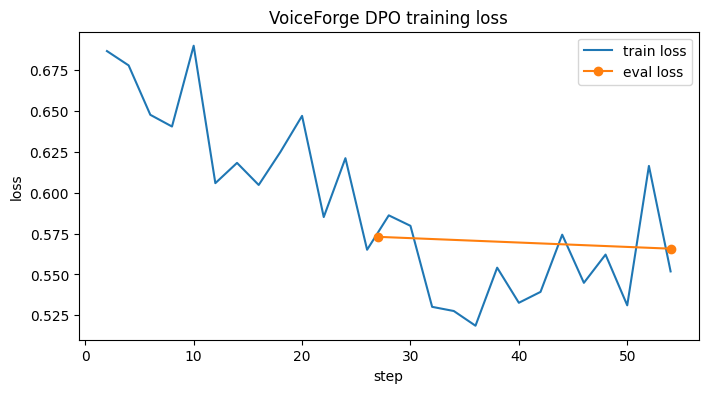

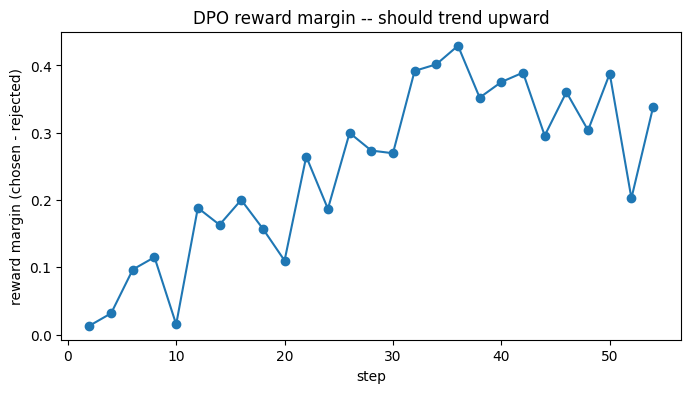

In [12]:
import matplotlib.pyplot as plt

history = trainer.state.log_history
train_steps = [h["step"] for h in history if "loss" in h and "eval_loss" not in h]
train_loss = [h["loss"] for h in history if "loss" in h and "eval_loss" not in h]
eval_steps = [h["step"] for h in history if "eval_loss" in h]
eval_loss = [h["eval_loss"] for h in history if "eval_loss" in h]

plt.figure(figsize=(8, 4))
plt.plot(train_steps, train_loss, label="train loss")
if eval_loss:
    plt.plot(eval_steps, eval_loss, label="eval loss", marker="o")
plt.xlabel("step")
plt.ylabel("loss")
plt.title("VoiceForge DPO training loss")
plt.legend()
plt.savefig(f"{DRIVE_PROJECT_DIR}/dpo_loss_curve.png", dpi=150, bbox_inches="tight")
plt.show()

# rewards/margins are DPO-specific and worth watching separately from loss --
# margin should trend upward as the model learns to separate chosen from rejected
margin_steps = [h["step"] for h in history if "rewards/margins" in h]
margins = [h["rewards/margins"] for h in history if "rewards/margins" in h]
if margins:
    plt.figure(figsize=(8, 4))
    plt.plot(margin_steps, margins, marker="o")
    plt.xlabel("step")
    plt.ylabel("reward margin (chosen - rejected)")
    plt.title("DPO reward margin -- should trend upward")
    plt.savefig(f"{DRIVE_PROJECT_DIR}/dpo_reward_margin.png", dpi=150, bbox_inches="tight")
    plt.show()


Both plots indicate successful DPO training. The decreasing training loss and stable evaluation loss suggest effective learning without significant overfitting. More importantly, the consistently increasing reward margin confirms that the model is successfully learning to prefer the 'chosen' responses over the 'rejected' ones, which is the primary objective of DPO.



## 10. Save and push the DPO adapter

In [13]:
DPO_ADAPTER_REPO = "bikalpoudel/voiceforge-brand-voice-dpo-lora"

FINAL_DPO_ADAPTER_DIR = f"{DRIVE_PROJECT_DIR}/final_dpo_adapter"
model.save_pretrained(FINAL_DPO_ADAPTER_DIR)
tokenizer.save_pretrained(FINAL_DPO_ADAPTER_DIR)
print(f"Saved adapter locally to {FINAL_DPO_ADAPTER_DIR}")

model.push_to_hub(DPO_ADAPTER_REPO, private=False)
tokenizer.push_to_hub(DPO_ADAPTER_REPO)
print(f"Pushed adapter to https://huggingface.co/{DPO_ADAPTER_REPO}")


Saved adapter locally to /content/drive/MyDrive/voiceforge/final_dpo_adapter


Processing Files (0 / 0)      : |          |  0.00B /  0.00B            

New Data Upload               : |          |  0.00B /  0.00B            

  ...adapter_model.safetensors:   0%|          | 46.2kB / 80.8MB            

  ...adapter_model.safetensors:   0%|          | 49.4kB /  162MB            

README.md:   0%|          | 0.00/5.17k [00:00<?, ?B/s]

Processing Files (0 / 0)      : |          |  0.00B /  0.00B            

New Data Upload               : |          |  0.00B /  0.00B            

  ...mpttzmdpy1/tokenizer.json:  70%|######9   | 7.99MB / 11.4MB            

Pushed adapter to https://huggingface.co/bikalpoudel/voiceforge-brand-voice-dpo-lora


## 11. Three-way qualitative check: base vs. SFT vs. SFT+DPO

Same `model.disable_adapter()` trick as Day 6, extended one step further:
this model currently has the DPO-trained adapter active, so
`disable_adapter()` gives base, and the adapter enabled gives SFT+DPO --
but to see the middle state (SFT-only, pre-DPO) too, we generate from
this same model right now (adapter on = SFT+DPO) and compare it against
what Day 6 already printed for SFT-only. If you want a true in-notebook
three-way (all in one run), keep Day 6's printed outputs handy to
compare against, or reload the SFT-only adapter separately.


In [14]:
import re

CLICHE_BLOCKLIST = {
    "cozy_crochet": [
        "elevate your accessory game", "must-have staple for your wardrobe",
        "unleash your style", "the ultimate fashion statement",
        "luxurious", "premium quality", "synergy", "game-changer",
        "game changer", "exclusive drop",
    ],
    "romantic_floral": [
        "unlock the secrets of romance", "unrivaled elegance for your lifestyle",
        "revolutionary floral technology", "cheap", "standard", "bulk",
        "commercial floral", "flash sale",
    ],
}

def has_banned_phrase(text, voice):
    text_lower = text.lower()
    return [p for p in CLICHE_BLOCKLIST[voice] if re.search(r"\b" + re.escape(p) + r"\b", text_lower)]

def generate_response(model, tokenizer, voice, brief, max_new_tokens=120):
    messages = [{"role": "system", "content": DISTILLED_SYSTEM_PROMPTS[voice]}, {"role": "user", "content": brief}]
    prompt = tokenizer.apply_chat_template(messages, tokenize=False, add_generation_prompt=True)
    inputs = tokenizer(prompt, return_tensors="pt").to(model.device)
    with torch.no_grad():
        out = model.generate(
            **inputs, max_new_tokens=max_new_tokens, do_sample=True,
            temperature=0.8, top_p=0.9, pad_token_id=tokenizer.pad_token_id,
        )
    return tokenizer.decode(out[0][inputs["input_ids"].shape[1]:], skip_special_tokens=True).strip()

model.config.use_cache = True
model.eval()

test_sample = sft_ds["test"].shuffle(seed=42).select(range(min(6, len(sft_ds["test"]))))

for row in test_sample:
    with model.disable_adapter():
        base_out = generate_response(model, tokenizer, row["voice"], row["brief"])
    dpo_out = generate_response(model, tokenizer, row["voice"], row["brief"])

    print(f"=== [{row['voice']}] {row['format']} ===")
    print("BRIEF:        ", row["brief"])
    print("BASE:         ", base_out)
    print("SFT+DPO:      ", dpo_out, "| banned phrases:", has_banned_phrase(dpo_out, row["voice"]) or "none")
    print()

model.config.use_cache = False


=== [cozy_crochet] restock_announcement ===
BRIEF:         [Voice: Cozy Crochet] Write a restock/drop announcement (15-30 words) for a crochet scarf. Campaign angle: gift guide for an upcoming occasion. Include a natural CTA encouraging DMs for orders or custom requests. Frame it as 'back' or 'new'.
BASE:          Back by popular demand: our 🧶 cozy cotton scarves perfect for last-minute gifts! 🌸 DM us for rush orders or custom lengths. 🛍️
SFT+DPO:       Our best-selling scarves are back in stock just in time for gift-giving season 🧶 Send us a message to order your favorite color! | banned phrases: none

=== [romantic_floral] etsy_listing ===
BRIEF:         [Voice: Romantic Floral] Write an Etsy-style product listing description (40-70 words, 3-5 sentences) for a graduation bouquet special. Campaign angle: care tip or fun fact about the piece. Include a natural CTA encouraging DMs for orders or custom requests. Must include at least one concrete, practical detail (turnaround time, size,

## Checks before Day 10:

- **Reward margin** trending upward over training (chosen scored higher
  than rejected, increasingly so).
- **Eval loss** not diverging sharply from train loss.
- **SFT+DPO outputs** vs. **base outputs**: same voice-adherence gap Day 6
  showed for SFT vs. base, ideally slightly sharper on the specific
  things DPO's preference pairs targeted (banned phrases, CTA rules).
- The saved Day 6's SFT-only outputs will be in for real three-way comarision side by side on the Day 10's formal evaluation.
- Adapter live at `https://huggingface.co/bikalpoudel/voiceforge-brand-voice-dpo-lora`.

Day 10 turns this qualitative read into an actual win-rate number
(LLM-as-judge, SFT+DPO vs. SFT-only, pairwise) plus a rubric score per
voice-guideline dimension.
